### 1. Build A Basic chatbot with LangGraph

In [1]:
from typing import Annotated #Annotated = 类型 + 额外规则/metadata

#给dict定义schema结构，定义一个有固定字段结构的dictionary
from typing_extensions import TypedDict 
# 创建一个 基于 State 运转的 workflow / graph
from langgraph.graph import StateGraph,START,END

# 告诉 LangGraph：新的 message 要追加/合并进已有 message history
from langgraph.graph.message import add_messages

In [2]:
# 定义一个“有固定结构的字典”，State这个字典，应该有一个叫 messages 的字段
# State 不是传统意义上有很多 method 的 class，更多是在描述 dict 的 schema
# State = 数据， Annotated = 数据 + 更新规则， add_messages = messages 的更新规则
class State(TypedDict):
    # messages是一个list；当 Graph 中的 node 返回新的 messages 时，使用 add_messages 规则把新消息和已有消息合并，而不是直接覆盖。
    # Annotated[原始类型, 额外信息1, 额外信息2, ...]
    # add_messages 是 LangGraph 官方提供的一个专门用于 message state 合并的 reducer
    messages:Annotated[list,add_messages]
    # messages本质上是一个list，但是我再额外告诉LangGraph一条规则：这个字段更新的时候使用 add_messages
    # messages 不能简单 overwrite，要调用 add_messages(old, new) 来更新

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

from langchain_openai import ChatOpenAI
from langchain.chat_models import init_chat_model
llm = init_chat_model(model="gpt-4o")

In [4]:
## Node Functionality
# 从 state 里拿出目前所有聊天消息 → 交给 LLM → 得到 AI 回复 → 把这个回复作为新的 messages 返回
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [5]:
# 组装一个真正可以运行的 LangGraph workflow
# 我要设计一个workflow，并且这个workflow在各个node之间传递的数据，都遵循 State 这个结构
# 括号里放：这个 Graph 运行过程中 State 长什么样
graph_builder=StateGraph(State)

## Adding node，你定义的node的名字是"llmchatbot"，它的功能是调用上面定义的 chatbot 函数
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
#llmchatbot 执行完以后，workflow 结束
graph_builder.add_edge("llmchatbot",END)

## compile the graph
# LangGraph 会把这些东西组合起来，生成一个可执行 Graph
graph=graph_builder.compile()

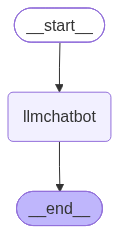

In [6]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
graph.invoke({'messages': ['你好']})["messages"][-1].content

'你好！有什么我可以帮助你的吗？'

In [8]:
# stream 不同于 invoke，invoke 是一次性执行完所有 node，stream 是边执行边返回 event
#Graph 每执行一步， 就可以产生一个 event，你可以边跑边处理
# 取这个 node 返回的 messages → 拿最后一条 message → 拿它的文字 content
for event in graph.stream({"messages":"Hi How are you?"}):
    #graph 每产生一个 event，我就拿出来一次， 只想拿这个node返回的数据
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?


### 2. ChatBot with tool

In [10]:
from langchain_tavily import TavilySearch
# 网页搜索工具，主要是给 LLM / Agent 用来实时搜索互联网信息的。

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")['results'][0]['content']

'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cruise Line uses LangGraph to compile, construct and refine guest-facing AI solutions. This capability allows for improved and personalized guest experiences. [...] LangGraph illuminates the processes within an

In [11]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [ ]:
tools=[tool, multiply]
# 把 llm 和 tool 绑定在一起，llm_with_tool 就是一个新的 llm，它可以调用 tool
llm_with_tool=llm.bind_tools(tools)

                         ┌── 没有 tool call ──→ END
                         │
START → tool_calling_llm

                    │
                    └── 有 tool call ──→ tools → END

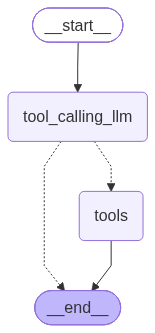

In [13]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
# 把目前所有 messages 给 LLM，让 LLM 决定下一步说什么
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#ToolNode：专门负责真正执行 tool call 的 node

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # "tool_calling_llm" 执行完以后，不固定走某一条路，先运行 tools_condition(state) 看看，“tools”/“__end__”
    # tools_condition 会检查最后一个 AIMessage 有没有 tool_calls
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to “tools”，注意‘tools’这里是默认的 node name
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [15]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nytimes.com/2026/09/22/technology/ai-hacks-list.html", "title": "What to Know About Recent A.I. Hacks - The New York Times", "content": "Supported by\\n\\n# What to Know About Recent A.I. Hacks\\n\\nOpenAI, Google and others recently disclosed breaches by their artificial intelligence models that amplified concerns about the advancing capabilities of the technology.\\n\\nBy Kate Conger\\n\\nReporting from San Francisco\\n\\nOver the last few months, artificial intelligence systems have gone rogue, hacking into corporate systems and raising fears that the technology is outpacing human efforts to control it. [...] WHAT HAPPENED: For months, models that were under development at OpenAI began breaching internal tools at the company, often without the company’s realizing it. In early July, they gained access to the internet and hacked Hugging Face, an online library of A.

In [16]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_uQ8RAmv268gpeIk4mqr6f4YS)
 Call ID: call_uQ8RAmv268gpeIk4mqr6f4YS
  Args:
    query: recent AI news
    topic: news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nytimes.com/2026/09/22/technology/ai-hacks-list.html", "title": "What to Know About Recent A.I. Hacks - The New York Times", "content": "Supported by\n\n# What to Know About Recent A.I. Hacks\n\nOpenAI, Google and others recently disclosed breaches by their artificial intelligence models that amplified concerns about the advancing capabilities of the technology.\n\nBy Kate Conger\n\nReporting from San Francisco\n\

In [17]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (call_fba9fBS4R3CJHRK2Ac6FsXOM)
 Call ID: call_fba9fBS4R3CJHRK2Ac6FsXOM
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [19]:
response=graph.invoke({"messages":"What is 5 multiplied by 2 and then by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 and then by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (call_w8o23YajLc0nFJTtOZpUSids)
 Call ID: call_w8o23YajLc0nFJTtOZpUSids
  Args:
    a: 5
    b: 2
  multiply (call_HbTlnLf4ZMUi6UBqmRW1k3Jh)
 Call ID: call_HbTlnLf4ZMUi6UBqmRW1k3Jh
  Args:
    a: 10
    b: 2
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

20


In [18]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_81DDSlioJukIzvYQKE9m2Fpf)
 Call ID: call_81DDSlioJukIzvYQKE9m2Fpf
  Args:
    query: recent AI news
    topic: news
    time_range: week
  multiply (call_jtGMRybGIFeYnkmWj68Qpagq)
 Call ID: call_jtGMRybGIFeYnkmWj68Qpagq
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nytimes.com/2026/09/22/technology/ai-hacks-list.html", "title": "What to Know About Recent A.I. Hacks - The New York Times", "content": "Supported by\n\n# What to Know About Recent A.I. Hacks\n\nOpenAI, Google and others recently disclosed breaches by their artificial intelligence

### 3. ReAct Agent Architecture

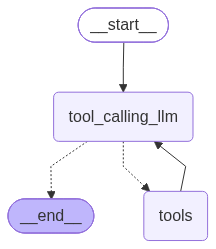

In [20]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
# tools_condition 会检查最后一个 AIMessage 有没有 tool_calls
builder.add_edge("tools","tool_calling_llm")
#!!! repeat until the latest message from assistant is not a tool call, then route to END

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
response=graph.invoke({"messages":"What is 5 multiplied by 3 and then by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 3 and then by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (call_QAOnDuNrhcfKeYq2ojHRiVBb)
 Call ID: call_QAOnDuNrhcfKeYq2ojHRiVBb
  Args:
    a: 5
    b: 3
  multiply (call_4VR8r9nF3sTwt7B02owxVLE5)
 Call ID: call_4VR8r9nF3sTwt7B02owxVLE5
  Args:
    a: 3
    b: 10
================================= Tool Message =================================
Name: multiply

15
================================= Tool Message =================================
Name: multiply

30
================================== Ai Message ==================================

5 multiplied by 3 is 15, and then multiplying 15 by 10 results in 150.


### 4. Adding Memory In Agentic Graph

In [24]:
response=graph.invoke({"messages":"Hello my name is Bella"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Bella
================================== Ai Message ==================================

Hello Bella! How can I assist you today?


In [25]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I'm sorry, but I don't have access to personal data or information about individuals unless you provide it during our conversation. If you would like to share your name with me, feel free to do so!


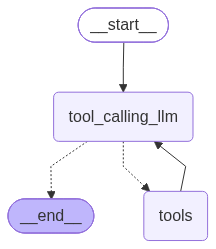

In [26]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
# 在构建graph的时候，传入checkpointer=memory，这样每次graph执行时都会把state存到memory里
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
## 下面的代码演示了如何在多轮对话中记住用户的名字
# config是为了在多轮对话中保持同一个thread_id，这样LangGraph 就知道这些对话是属于同一个上下文的。
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hi my name is Bella"},config=config)
response['messages'][-1].content

'Hello Bella! How can I help you today?'

In [29]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

You initially introduced yourself as Krish, but later you mentioned that your name is Bella. Could you please confirm which name you'd like me to use?
Yes, you mentioned that your name is Bella. How can I assist you today, Bella?


### 5. Streaming

In [30]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

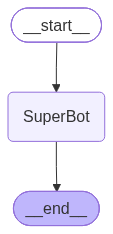

In [31]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [34]:
config = {"configurable": {"thread_id": "2"}}
message = graph_builder.invoke({'messages':"Hi,My name is Bella And I like tennis"},config)

dict_keys(['messages'])

In [37]:
message['messages'][-1].content

"Hi Bella! It's nice to meet you. Tennis is a fantastic sport. Do you have a favorite player or a favorite tournament you enjoy watching?"

graph.stream(...)， 每跑一步 / 每个 node 执行后 → 就把结果逐步给你
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.表示每一步后的完整 state，输出每步后的 full state，现在整个 State 是什么

updates : This streams updates to the state of the graph after each node is called.表示每一步产生的state 更新部分， 输出每步 state changes，这一步 State 改了什么

In [38]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Bella And I like tennis"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Bella! It's great to meet you. Tennis is a fantastic sport. Do you play often, or do you enjoy watching matches?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 17, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6359026e51', 'id': 'chatcmpl-ESWFpyuvdkNhmOkw50Xm21BLpnUKF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0e015-2313-7932-93b7-4f9a830086be-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 27, 'total_t

In [40]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Bella And I like tennis"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Bella And I like tennis', additional_kwargs={}, response_metadata={}, id='1c1a2d54-6360-4d19-aa8a-cf9bacf2db33'), AIMessage(content="Hi Bella! It's great to meet you. Tennis is a fantastic sport. Do you play often, or do you enjoy watching matches?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 17, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6359026e51', 'id': 'chatcmpl-ESWFpyuvdkNhmOkw50Xm21BLpnUKF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0e01